The parameter that changes each iteration is `AQ`, which depends on Q. So the gradient needed is:

$$\frac{\partial \text{loss}}{\partial \mathbf{Q}} = \frac{\partial \text{loss}}{\partial \mathbf{w}^*} \frac{\partial \mathbf{w}^*}{\partial \mathbf{AQ}} \frac{\partial \mathbf{AQ}}{\partial \mathbf{Q}}$$

`cvxpylayers` handles the middle term $\frac{\partial \mathbf{w}^*}{\partial \mathbf{AQ}}$ — differentiating through the QP with respect to its **parameters**. So yes, the setup is:

1. Define the QP in `cvxpy` with `AQ` as a **parameter**
2. Wrap with `CvxpyLayer`
3. Q is a `torch` tensor with `requires_grad=True`
4. Compute `AQ = A @ Q` in torch (so the `AQ -> Q` gradient is tracked)
5. Pass `AQ` to the layer, get `w*`
6. Compute loss, call `loss.backward()`

PyTorch handles step 4 automatically, and `cvxpylayers` handles the differentiation through the QP in step 5. So yes, I believe the suggestion is correct. The full chain is differentiable end to end.

In [1]:
import sys
print(sys.executable)

/Users/jseid1/venv311/bin/python


In [ ]:
import torch
import numpy as np
import cvxpy as cp
# import cvxopt


# will only be run one time
# begin with random matrix, but then
# gradient descent to better solution.
def generateQ(c):
    mean = np.ones(c)
    cov = np.identity(c)
    # 2 is number of rows
    Q = np.random.multivariate_normal(mean, cov, 2)
    return Q

    
def experiment(embedding_dim):
    c = embedding_dim
    # target vector
    d = np.array([6.0, 2.0], dtype=np.float64)
    # fill by row
    A = torch.tensor([[2, 4], [3, 5]], dtype=torch.float64)
    # the initial lifting matrix
    Q = generateQ(c)

    # For the given Q, we want to find the optimal w
    # a vector of length c
    w = cp.Variable(c)
    # dim 2 is arbitrary here.
    AQ = cp.Parameter((2, c))

    # The problem of finding optimal weights,
    # given a target vector and (lifted) covariate matrix
    objective = cp.Minimize(cp.sum_squares(d - AQ @ w))
    constraints = [cp.sum(w) == 1, w >= 0]
    prob = cp.Problem(objective, constraints)
    prob.solve()









(CVXPY) Mar 24 09:31:29 AM: Encountered unexpected exception importing solver DIFFCP:
ImportError('diffcp >= 1.0.15 is required')


In [35]:
# thanks Claude.

import numpy as np
import torch
import cvxpy as cp
from cvxpylayers.torch import CvxpyLayer

# Data
d = torch.tensor([6.0, 2.0], dtype=torch.float64)
A = torch.tensor([[2.0, 4.0], [3.0, 5.0]], dtype=torch.float64)

# Embedding dimension
c = 10

# Q is what we're optimizing - requires_grad=True tracks gradients
torch.manual_seed(215)
Q = torch.randn(2, c, dtype=torch.float64, requires_grad=True)

# --- Define the inner QP once (structure never changes) ---
w_var = cp.Variable(c)
AQ_param = cp.Parameter((2, c))
objective = cp.Minimize(cp.sum_squares(d.numpy() - AQ_param @ w_var))
constraints = [cp.sum(w_var) == 1, w_var >= 0]
prob = cp.Problem(objective, constraints)
layer = CvxpyLayer(prob, parameters=[AQ_param], variables=[w_var])

# --- Outer optimization loop ---
optimizer = torch.optim.Adam([Q], lr=0.01)

for step in range(2000):
    optimizer.zero_grad()

    # transform the covariates using Q
    AQ = A @ Q                      
    # solve for w given the matrix Q
    w_sol, = layer(AQ)  
    # loss using the optimal w for this Q
    loss = torch.sum((d - AQ @ w_sol)**2)

    # this is where Q is updated
    loss.backward()                 
    optimizer.step()
    
    if step % 200 == 0:
        print(f"Step {step:4d} | Loss: {loss.item():.8f}")

# --- Results ---
print(f"\nFinal Loss: {loss.item():.8f}")
#print(f"Final w:    {w_sol.detach().numpy().round(4)}")
#print(f"AQ @ w:     {(AQ @ w_sol).detach().numpy().round(4)}")
#print(f"Target d:   {d.numpy()}")
#print(f"Final Q:\n {Q.detach().numpy().round(4)}")

Q_final = Q.detach().numpy()
w_final = w_sol.detach().numpy()

Step    0 | Loss: 17.74890628
Step  200 | Loss: 6.43321520
Step  400 | Loss: 3.49763663
Step  600 | Loss: 1.80395810
Step  800 | Loss: 0.85490594
Step 1000 | Loss: 0.36437040
Step 1200 | Loss: 0.13723119
Step 1400 | Loss: 0.04479033
Step 1600 | Loss: 0.01251527
Step 1800 | Loss: 0.00295655

Final Loss: 0.00045873


Without regularization, the matrix $Q$ overfits terribly. The problem is that $Q$ learns to encode the target vector, and $\vec{w}$ simply puts a 1 in the appropriate index. Would this happen with higher dimensional target and covariate data? In addition, in the real case, we will have multiple covariate matrices $A_t$ and only one matrix $Q$. Perhaps this will act as implicit regularizization since the problem is harder to solve.

Overfitting:

In [36]:
# overfitting
print("Final Weights:")
print(w_final.round(2))

AQ_final = A.numpy() @ Q_final
result = AQ_final @ w_final

print("\nOverfitting results:")
print("Target: ", d.numpy())
print("Result: ", result[0:2])

Final Weights:
[-0. -0.  1. -0. -0. -0. -0. -0. -0. -0.]

Overfitting results:
Target:  [6. 2.]
Result:  [5.98438982 2.01454522]


One kind of regularization is to fix every weight at $1/n$. 
- Would this simply re-impose the simplex constraint that $Q$ is designed to work around?
- Would an L1 penalty on the weights be more appropriate?

Below is a function that runs gradient descent to find the optimal $Q$ with fixed weights.

In [55]:
import numpy as np
import torch
import cvxpy as cp
from cvxpylayers.torch import CvxpyLayer

# get around over fitting with equal weights?
# d = torch.tensor([6.0, 2.0], dtype=torch.float64)
# A = torch.tensor([[2.0, 4.0], [3.0, 5.0]], dtype=torch.float64)

def fixed_weights_experiment(target, covariates, embedding_dim, verbose):
    # extract number of predictors from dimension of target vector
    num_predictors = target.shape[0]

    # Q is what we're optimizing - requires_grad=True tracks gradients
    Q = torch.randn(num_predictors, embedding_dim, dtype=torch.float64, requires_grad=True)
    
    
    # Fixed equal weights
    w_fixed = torch.ones(embedding_dim, dtype=torch.float64) / embedding_dim
    
    # Outer optimization loop
    optimizer = torch.optim.Adam([Q], lr=0.01)
    
    for step in range(2000):
        optimizer.zero_grad()
        
        AQ = covariates @ Q
        loss = torch.sum((target - AQ @ w_fixed)**2)
        
        loss.backward()
        optimizer.step()

        if (verbose == True):
            if step % 200 == 0:
                print(f"Step {step:4d} | Loss: {loss.item():.8f}")
    
    # Output results
    if (verbose == True): 
        Q_final = Q.detach().numpy()
        w_final = w_fixed.numpy()
        AQ_final = covariates.numpy() @ Q_final
        print(f"\nFinal Loss: {loss.item():.8f}")
        print(f"Original Covariates:\n {A.numpy()}")
        print(f"Lifted Covariates:\n {AQ_final.round(3)}")
        print(f"A @ Q @ w: {(AQ_final @ w_final).round(4)}")
        print(f"Target d:  {d.numpy()}")
        Q_final = Q.detach().numpy()
        
    return (loss.item())


Run the experiment with fixed weights and embed from $\mathbb{R}^{2\times 2}$ to $\mathbb{R}^{2\times 3}$:

In [57]:
torch.manual_seed(215)
fixed_weights_experiment(d, A,3,True)

Step    0 | Loss: 16.67325448
Step  200 | Loss: 11.63313647
Step  400 | Loss: 9.22020199
Step  600 | Loss: 6.90049399
Step  800 | Loss: 4.92449950
Step 1000 | Loss: 3.35751008
Step 1200 | Loss: 2.18319289
Step 1400 | Loss: 1.34863439
Step 1600 | Loss: 0.78718691
Step 1800 | Loss: 0.43131309

Final Loss: 0.22096145
Original Covariates:
 [[2. 4.]
 [3. 5.]]
Lifted Covariates:
 [[ 1.266 10.936  4.676]
 [-3.318  9.387  0.782]]
A @ Q @ w: [5.6261 2.2835]
Target d:  [6. 2.]


0.22096144550661512

With fixed weights, as the embdedding dimension grows, the loss *does not* get better:

In [ ]:

fixed_weights_experiment(d, A, 10,True)

Step    0 | Loss: 98.20947647
Step  200 | Loss: 13.26715855
Step  400 | Loss: 12.95192226
Step  600 | Loss: 12.53990655
Step  800 | Loss: 12.04376283
Step 1000 | Loss: 11.47521081
Step 1200 | Loss: 10.84433685
Step 1400 | Loss: 10.16089338
Step 1600 | Loss: 9.43487288
Step 1800 | Loss: 8.67676129

Final Loss: 7.90153418
Original Covariates:
 [[2. 4.]
 [3. 5.]]
Lifted Covariates:
 [[-2.333  5.497  3.213  3.847  1.334  8.421  9.044  0.213  3.662  4.607]
 [-4.827  6.122  3.421  3.751 -0.278  9.907 10.542  0.459  3.524  4.224]]
A @ Q @ w: [3.7505 3.6844]
Target d:  [6. 2.]


7.901534176424525

This shows that increasing the embedding dimension does not help with mitigating the loss, once we fix the weights at $1/n$.

[0.07470460657525331, 0.1499520621075922, 0.15273558430676018, 0.17493605581844968, 0.07476386012340357, 0.11281793825861322, 0.03059821315976685, 0.0792627255807416, 0.021083558014995007, 0.08476809221296408, 0.2724026394149316, 0.020473204746652075, 0.018662392275651925, 0.027547329325980953, 0.6944356212991689, 0.02589048220148014, 0.04584493117863415, 0.10184598655232861, 0.1469257627257617, 0.1145552364793836]


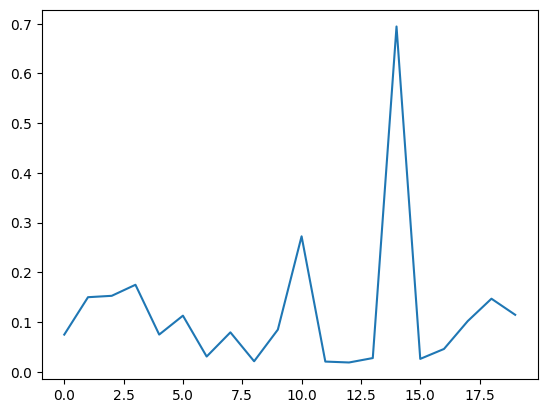

In [ ]:
# running the fixed weights experiment many times
import matplotlib.pyplot as plt
torch.manual_seed(215)
mean_losses = []
for i in range(20):
    losses = []
    # run 5 times to get an average for each embedding dimension
    for j in range(5):
        d = torch.rand(20)
        A = torch.randn(20, 20, dtype=torch.float64)
        # run the fixed weights experiment, embedding into the original dimension, plus i
        losses.append(fixed_weights_experiment(d, A,20+i,False))
    mean_loss = sum(losses) / len(losses)
    mean_losses.append(mean_loss)

print(mean_losses)
plt.plot(mean_losses)
plt.show()